# Calibrating Agricultural Water Demand in India with a Differentiable ABM

This notebook follows the project proposal and builds a **data-driven representative-agent framework** for agricultural water demand in India.

Regions studied:
- Punjab
- West Bengal
- Maharashtra

Pipeline:
1. Load and clean crop-yield data.
2. Download weather and macro water indicators from external resources.
3. Engineer ABM-consistent features (soil moisture deficit proxies, crop water requirements, economic signal).
4. Train a baseline ML model and a differentiable ABM-style model.
5. Compare performance and visualize policy/climate scenarios.

> Note: District-level observed irrigation demand is not directly available in this repository. We construct a transparent proxy target from agronomic relationships and external indicators, then calibrate the D-ABM against that proxy.


In [1]:
# Core imports
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import requests

import matplotlib.pyplot as plt

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn

# Optional seaborn with matplotlib fallback
try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    HAS_SEABORN = False

    class _SNSFallback:
        def set_theme(self, **kwargs):
            return None

        def lineplot(self, data, x, y, hue=None, marker=None, ax=None, **kwargs):
            ax = ax or plt.gca()
            if hue is None:
                ax.plot(data[x], data[y], marker=marker)
            else:
                for k, g in data.groupby(hue):
                    ax.plot(g[x], g[y], marker=marker, label=str(k))
                ax.legend()
            return ax

        def scatterplot(self, data, x, y, hue=None, size=None, alpha=1.0, ax=None, **kwargs):
            ax = ax or plt.gca()
            if size is not None:
                svals = data[size]
                s_scaled = 20 + 180 * (svals - svals.min()) / (svals.max() - svals.min() + 1e-9)
            else:
                s_scaled = 50
            if hue is None:
                ax.scatter(data[x], data[y], s=s_scaled, alpha=alpha)
            else:
                for k, g in data.groupby(hue):
                    if size is not None:
                        sg = 20 + 180 * (g[size] - data[size].min()) / (data[size].max() - data[size].min() + 1e-9)
                    else:
                        sg = 50
                    ax.scatter(g[x], g[y], s=sg, alpha=alpha, label=str(k))
                ax.legend()
            return ax

        def heatmap(self, data, annot=False, fmt='.1f', cmap='viridis', ax=None, **kwargs):
            ax = ax or plt.gca()
            arr = np.asarray(data)
            im = ax.imshow(arr, cmap=cmap, aspect='auto')
            ax.set_xticks(np.arange(arr.shape[1]))
            ax.set_xticklabels(list(data.columns), rotation=45, ha='right')
            ax.set_yticks(np.arange(arr.shape[0]))
            ax.set_yticklabels(list(data.index))
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            if annot:
                for i in range(arr.shape[0]):
                    for j in range(arr.shape[1]):
                        ax.text(j, i, format(arr[i, j], fmt), ha='center', va='center', fontsize=8)
            return ax

        def barplot(self, data, x, y, hue=None, ax=None, **kwargs):
            ax = ax or plt.gca()
            if hue is None:
                ax.bar(data[x].astype(str), data[y])
            else:
                piv = data.pivot(index=x, columns=hue, values=y)
                piv.plot(kind='bar', ax=ax)
            return ax

    sns = _SNSFallback()

# Plot style for inline/interactive rendering
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
print("Seaborn available:", HAS_SEABORN)


Seaborn available: False


In [2]:
# Paths
ROOT = Path.cwd()
DATA_PATH = ROOT / "data_crop_yield.csv"
DOWNLOAD_DIR = ROOT / "downloaded_data"
OUTPUT_DIR = ROOT / "agri_water_demand_outputs"
DOWNLOAD_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Missing dataset: {DATA_PATH}")

print("Working directory:", ROOT)
print("Main data file:", DATA_PATH)


Working directory: f:\IIT KGP\sem10\Stats in AIML\Course Project
Main data file: f:\IIT KGP\sem10\Stats in AIML\Course Project\data_crop_yield.csv


## 1) Load Core Agricultural Data

In [3]:
crop_df = pd.read_csv(DATA_PATH)
crop_df.columns = [c.strip() for c in crop_df.columns]

# Basic cleanup
crop_df["State"] = crop_df["State"].astype(str).str.strip()
crop_df["Crop"] = crop_df["Crop"].astype(str).str.strip()
crop_df["Season"] = crop_df["Season"].astype(str).str.strip()

numeric_cols = ["Area", "Production", "Annual_Rainfall", "Fertilizer", "Pesticide", "Yield"]
for col in numeric_cols:
    crop_df[col] = pd.to_numeric(crop_df[col], errors="coerce")

crop_df = crop_df.dropna(subset=["State", "Crop", "Crop_Year", "Area", "Annual_Rainfall", "Yield"])
crop_df["Crop_Year"] = crop_df["Crop_Year"].astype(int)

print("Shape:", crop_df.shape)
print("Years:", crop_df["Crop_Year"].min(), "to", crop_df["Crop_Year"].max())
print("States:", crop_df["State"].nunique())


Shape: (19689, 10)
Years: 1997 to 2020
States: 30


## 2) Download External Data from Multiple Sources

We download from:
- **NASA POWER API**: daily weather variables (rainfall, temperature) by region centroid.
- **World Bank API**: national water indicators to provide macro hydrology context.


In [4]:
# Region metadata for proposal focus states
state_meta = {
    "Punjab": {"lat": 31.1471, "lon": 75.3412},
    "West Bengal": {"lat": 22.9868, "lon": 87.8550},
    "Maharashtra": {"lat": 19.7515, "lon": 75.7139},
}

start_year = int(crop_df["Crop_Year"].min())
end_year = int(crop_df["Crop_Year"].max())


def fetch_nasa_power(state, lat, lon, start_year, end_year, out_dir=DOWNLOAD_DIR):
    # Download daily precipitation and temperature from NASA POWER.
    out_file = out_dir / f"nasa_power_{state.lower().replace(' ', '_')}.csv"
    if out_file.exists():
        cached = pd.read_csv(out_file)
        if "year" not in cached.columns and "date" in cached.columns:
            cached["date"] = pd.to_datetime(cached["date"], errors="coerce")
            cached["year"] = cached["date"].dt.year
        if "state" not in cached.columns:
            cached["state"] = state
        return cached

    url = (
        "https://power.larc.nasa.gov/api/temporal/daily/point"
        f"?parameters=PRECTOTCORR,T2M_MAX,T2M_MIN"
        f"&community=AG&longitude={lon}&latitude={lat}"
        f"&start={start_year}0101&end={end_year}1231&format=JSON"
    )

    r = requests.get(url, timeout=60)
    r.raise_for_status()
    payload = r.json()
    param = payload["properties"]["parameter"]

    dates = sorted(param["PRECTOTCORR"].keys())
    rows = []
    for d in dates:
        rows.append({
            "date": d,
            "PRECTOTCORR": param["PRECTOTCORR"].get(d, np.nan),
            "T2M_MAX": param["T2M_MAX"].get(d, np.nan),
            "T2M_MIN": param["T2M_MIN"].get(d, np.nan),
        })

    weather = pd.DataFrame(rows)
    weather["date"] = pd.to_datetime(weather["date"], format="%Y%m%d")
    weather["year"] = weather["date"].dt.year
    weather["state"] = state

    weather.to_csv(out_file, index=False)
    return weather


all_weather = []
for st, meta in state_meta.items():
    try:
        w = fetch_nasa_power(st, meta["lat"], meta["lon"], start_year, end_year)
        all_weather.append(w)
        print(f"Downloaded/loaded weather for {st}: {w.shape}")
    except Exception as e:
        print(f"Weather download failed for {st}: {e}")

if all_weather:
    weather_df = pd.concat(all_weather, ignore_index=True)
else:
    weather_df = pd.DataFrame(columns=["date", "PRECTOTCORR", "T2M_MAX", "T2M_MIN", "year", "state"])

weather_df.head()


Downloaded/loaded weather for Punjab: (8766, 6)
Downloaded/loaded weather for West Bengal: (8766, 6)
Downloaded/loaded weather for Maharashtra: (8766, 6)


,date,PRECTOTCORR,T2M_MAX,T2M_MIN,state,year
0,1970-01-01 00:00:00.019970101,0.0,24.55,9.77,Punjab,1970
1,1970-01-01 00:00:00.019970102,0.0,23.50,8.51,Punjab,1970
2,1970-01-01 00:00:00.019970103,0.0,23.35,9.34,Punjab,1970
3,1970-01-01 00:00:00.019970104,0.0,21.07,6.84,Punjab,1970
4,1970-01-01 00:00:00.019970105,0.0,23.03,6.86,Punjab,1970


In [5]:
def fetch_world_bank_indicator(indicator_code, country="IND", out_dir=DOWNLOAD_DIR):
    out_file = out_dir / f"world_bank_{indicator_code.replace('.', '_')}.csv"
    if out_file.exists():
        return pd.read_csv(out_file)

    url = f"https://api.worldbank.org/v2/country/{country}/indicator/{indicator_code}?format=json&per_page=20000"
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    payload = r.json()

    if len(payload) < 2 or payload[1] is None:
        return pd.DataFrame(columns=["year", "value", "indicator"])

    rows = []
    for rec in payload[1]:
        rows.append({
            "year": pd.to_numeric(rec.get("date"), errors="coerce"),
            "value": rec.get("value"),
            "indicator": indicator_code,
        })

    df = pd.DataFrame(rows).dropna(subset=["year"]).copy()
    df["year"] = df["year"].astype(int)
    df.to_csv(out_file, index=False)
    return df

# Relevant hydrology indicators for India
indicator_codes = [
    "ER.H2O.FWAG.ZS",   # Freshwater withdrawals for agriculture (% of total)
    "AG.LND.IRIG.AG.ZS",# Irrigated agricultural land (% of total ag land)
]

wb_frames = []
for code in indicator_codes:
    try:
        dfi = fetch_world_bank_indicator(code)
        wb_frames.append(dfi)
        print(code, dfi.shape)
    except Exception as e:
        print(f"World Bank download failed for {code}: {e}")

if wb_frames:
    wb_df = pd.concat(wb_frames, ignore_index=True)
else:
    wb_df = pd.DataFrame(columns=["year", "value", "indicator"])

wb_df.head()


ER.H2O.FWAG.ZS (66, 3)
AG.LND.IRIG.AG.ZS (66, 3)


,year,value,indicator
0,2025,NaN,ER.H2O.FWAG.ZS
1,2024,NaN,ER.H2O.FWAG.ZS
2,2023,NaN,ER.H2O.FWAG.ZS
3,2022,90.407359,ER.H2O.FWAG.ZS
4,2021,90.407359,ER.H2O.FWAG.ZS


## 3) Representative-Agent Dataset Construction

In [6]:
focus_states = list(state_meta.keys())
model_df = crop_df[crop_df["State"].isin(focus_states)].copy()

# Keep major crops for representative-agent tractability
top_crops = (
    model_df.groupby("Crop")["Area"]
    .sum()
    .sort_values(ascending=False)
    .head(12)
    .index
)
model_df = model_df[model_df["Crop"].isin(top_crops)].copy()

# Aggregate to representative agents: (state, year, crop)
agent_df = (
    model_df.groupby(["State", "Crop_Year", "Crop"], as_index=False)
    .agg({
        "Area": "sum",
        "Production": "sum",
        "Annual_Rainfall": "mean",
        "Fertilizer": "sum",
        "Pesticide": "sum",
        "Yield": "mean",
    })
)

# Weather features from NASA (annual summaries)
if not weather_df.empty:
    weather_annual = (
        weather_df.groupby(["state", "year"], as_index=False)
        .agg({
            "PRECTOTCORR": "sum",
            "T2M_MAX": "mean",
            "T2M_MIN": "mean",
        })
        .rename(columns={
            "state": "State",
            "year": "Crop_Year",
            "PRECTOTCORR": "nasa_rain_mm",
            "T2M_MAX": "nasa_tmax_c",
            "T2M_MIN": "nasa_tmin_c",
        })
    )
else:
    weather_annual = pd.DataFrame(columns=["State", "Crop_Year", "nasa_rain_mm", "nasa_tmax_c", "nasa_tmin_c"])

agent_df = agent_df.merge(weather_annual, on=["State", "Crop_Year"], how="left")

# Prefer NASA rainfall where available, else local rainfall
agent_df["rain_mm"] = agent_df["nasa_rain_mm"].fillna(agent_df["Annual_Rainfall"])
agent_df["temp_mean_c"] = (agent_df["nasa_tmax_c"] + agent_df["nasa_tmin_c"]) / 2
agent_df["temp_mean_c"] = agent_df["temp_mean_c"].fillna(27.0)

# Crop water requirement lookup (mm per growing season, approximate)
cwr_lookup = {
    "Rice": 1200, "Wheat": 550, "Maize": 500, "Sugarcane": 1600,
    "Cotton(lint)": 850, "Soyabean": 450, "Jowar": 450, "Bajra": 400,
    "Gram": 350, "Arhar/Tur": 450, "Niger seed": 350, "Jute": 700,
}
agent_df["cwr_mm"] = agent_df["Crop"].map(cwr_lookup).fillna(600)

# Agronomic features
agent_df["deficit_mm"] = (agent_df["cwr_mm"] - 0.65 * agent_df["rain_mm"]).clip(lower=0)
agent_df["fert_per_ha"] = agent_df["Fertilizer"] / (agent_df["Area"] + 1e-6)
agent_df["pest_per_ha"] = agent_df["Pesticide"] / (agent_df["Area"] + 1e-6)

# Economic signal proxy: state-year relative yield performance
state_year_yield = agent_df.groupby(["State", "Crop_Year"])["Yield"].transform("mean")
agent_df["econ_signal"] = (agent_df["Yield"] / (state_year_yield + 1e-6)).clip(0.5, 1.5)

# Transparent observed-demand proxy for calibration target
fert_scaled = (agent_df["fert_per_ha"] - agent_df["fert_per_ha"].min()) / (agent_df["fert_per_ha"].max() - agent_df["fert_per_ha"].min() + 1e-9)

agent_df["irr_proxy_mm_base"] = (
    0.75 * agent_df["deficit_mm"]
    + 0.15 * fert_scaled * agent_df["cwr_mm"]
    + 0.10 * (1.2 - agent_df["econ_signal"]).clip(lower=0) * agent_df["cwr_mm"]
).clip(lower=0)

# Merge World Bank irrigation context
if not wb_df.empty:
    wb_irrig = wb_df[wb_df["indicator"] == "AG.LND.IRIG.AG.ZS"][["year", "value"]].rename(columns={"year": "Crop_Year", "value": "wb_irrig_pct"})
    agent_df = agent_df.merge(wb_irrig, on="Crop_Year", how="left")
    med = agent_df["wb_irrig_pct"].median()
    agent_df["wb_irrig_pct"] = agent_df["wb_irrig_pct"].fillna(med if pd.notna(med) else 35.0)
    wb_scale = agent_df["wb_irrig_pct"] / (agent_df["wb_irrig_pct"].max() + 1e-6)
else:
    wb_scale = 0.7

agent_df["observed_irrig_mm"] = agent_df["irr_proxy_mm_base"] * (0.8 + 0.4 * wb_scale)

# Convert irrigation depth to volume: mcm = mm * ha * 1e-5
agent_df["observed_demand_mcm"] = agent_df["observed_irrig_mm"] * agent_df["Area"] * 1e-5

agent_df = agent_df.sort_values(["State", "Crop_Year", "Crop"]).reset_index(drop=True)
print("Representative-agent rows:", len(agent_df))
agent_df.head()


Representative-agent rows: 708


,State,Crop_Year,Crop,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,nasa_rain_mm,...,temp_mean_c,cwr_mm,deficit_mm,fert_per_ha,pest_per_ha,econ_signal,irr_proxy_mm_base,wb_irrig_pct,observed_irrig_mm,observed_demand_mcm
0,Maharashtra,1997,Arhar/Tur,1005600.0,348000,1156.1,9.570295e+07,311736.00,0.332500,NaN,...,27.0,450,0.000,95.17,0.31,0.5,31.937800,35.341649,36.847681,370.540278
1,Maharashtra,1997,Bajra,1671200.0,1119000,1156.1,1.590481e+08,518072.00,0.632273,NaN,...,27.0,400,0.000,95.17,0.31,0.5,28.389156,35.341649,32.753494,547.376392
2,Maharashtra,1997,Cotton(lint),31292.0,1753100,1156.1,2.978060e+06,9700.52,95.993913,NaN,...,27.0,850,98.535,95.17,0.31,1.5,74.728206,35.341649,86.216366,26.978825
3,Maharashtra,1997,Gram,717100.0,295900,1156.1,6.824641e+07,222301.00,0.408148,NaN,...,27.0,350,0.000,95.17,0.31,0.5,24.840511,35.341649,28.659307,205.515893
4,Maharashtra,1997,Jowar,5500200.0,3989800,1156.1,5.234540e+08,1705062.00,1.044442,NaN,...,27.0,450,0.000,95.17,0.31,0.5,31.937800,35.341649,36.847681,2026.696139


## 4) Exploratory Visualization

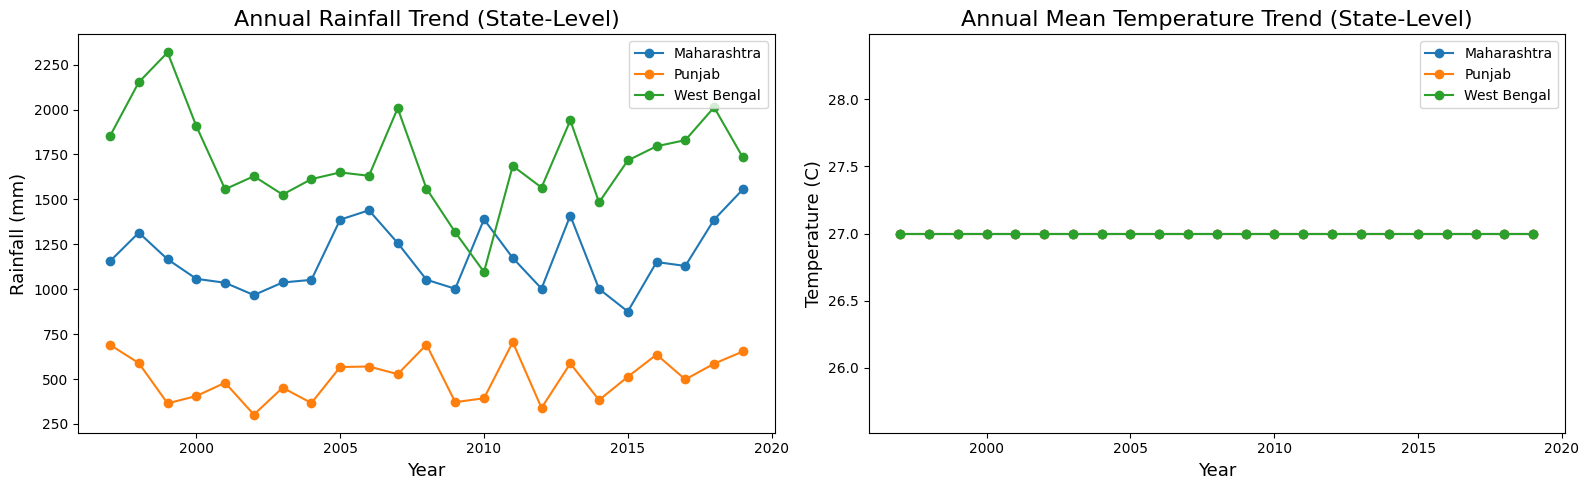

In [7]:
# Rainfall and temperature trends by state
annual_state = (
    agent_df.groupby(["State", "Crop_Year"], as_index=False)
    .agg({"rain_mm": "mean", "temp_mean_c": "mean"})
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=annual_state, x="Crop_Year", y="rain_mm", hue="State", marker="o", ax=axes[0])
axes[0].set_title("Annual Rainfall Trend (State-Level)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Rainfall (mm)")

sns.lineplot(data=annual_state, x="Crop_Year", y="temp_mean_c", hue="State", marker="o", ax=axes[1])
axes[1].set_title("Annual Mean Temperature Trend (State-Level)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Temperature (C)")

plt.tight_layout()
plt.show()


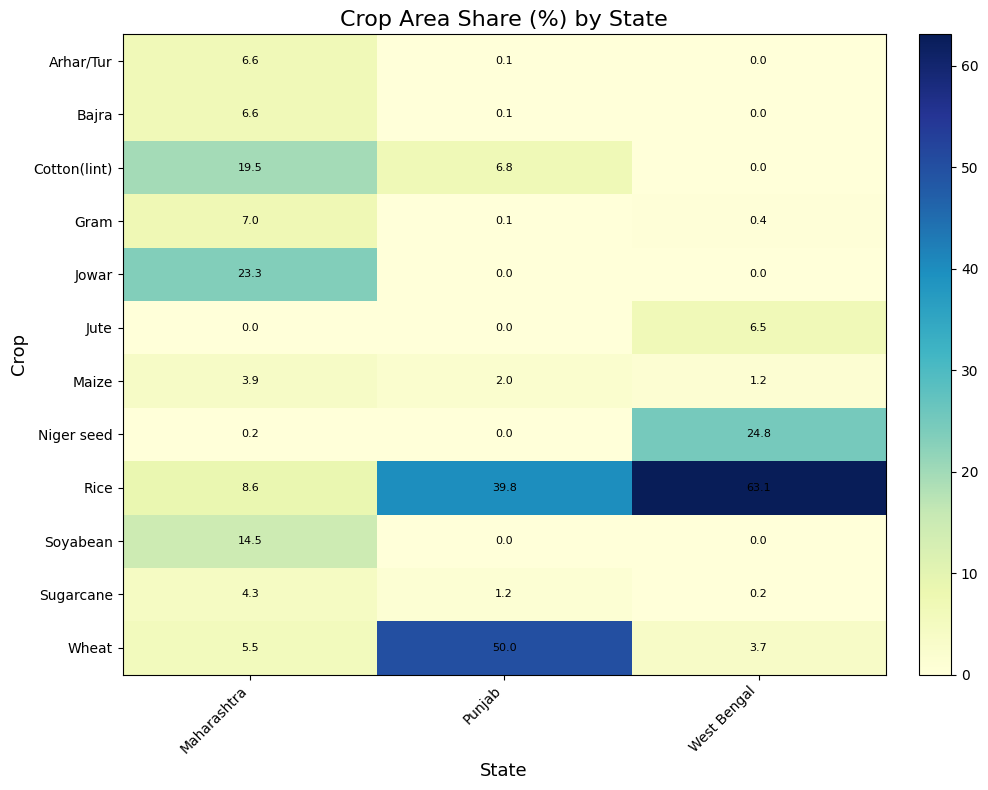

In [8]:
# Crop area mix heatmap
crop_mix = agent_df.groupby(["State", "Crop"], as_index=False)["Area"].sum()
crop_mix["area_share_pct"] = 100 * crop_mix["Area"] / crop_mix.groupby("State")["Area"].transform("sum")

pivot = crop_mix.pivot(index="Crop", columns="State", values="area_share_pct").fillna(0)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Crop Area Share (%) by State")
plt.xlabel("State")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()


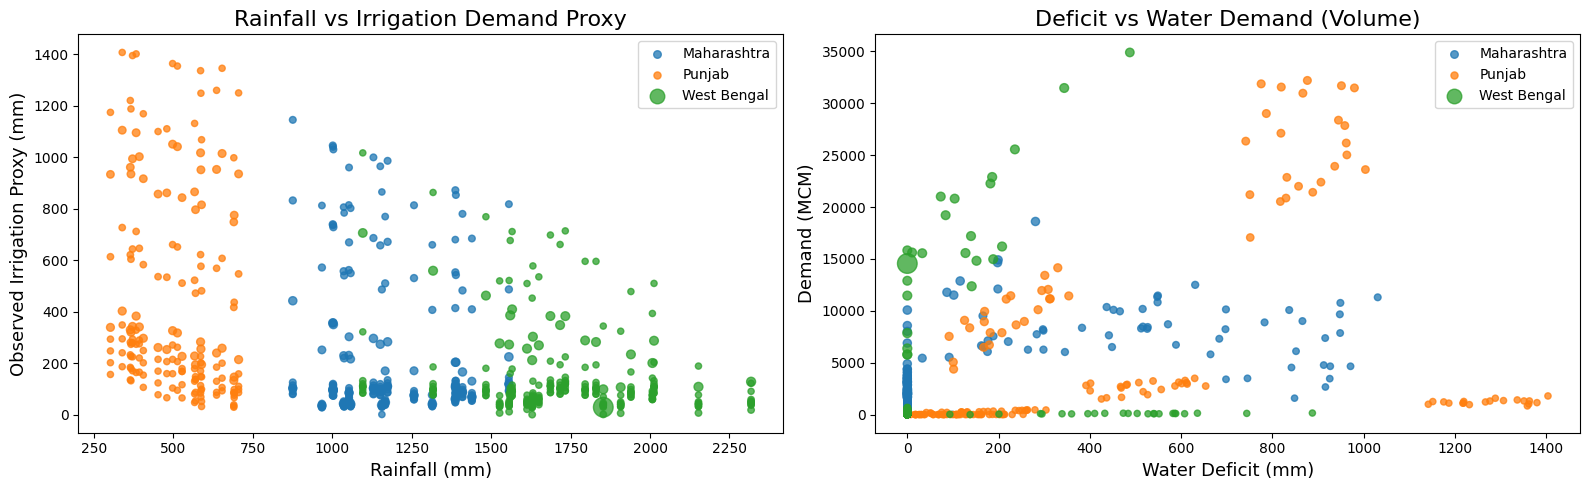

In [9]:
# Rainfall-deficit-demand relationships
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.scatterplot(
    data=agent_df,
    x="rain_mm",
    y="observed_irrig_mm",
    hue="State",
    size="Area",
    alpha=0.75,
    ax=axes[0]
)
axes[0].set_title("Rainfall vs Irrigation Demand Proxy")
axes[0].set_xlabel("Rainfall (mm)")
axes[0].set_ylabel("Observed Irrigation Proxy (mm)")

sns.scatterplot(
    data=agent_df,
    x="deficit_mm",
    y="observed_demand_mcm",
    hue="State",
    size="Area",
    alpha=0.75,
    ax=axes[1]
)
axes[1].set_title("Deficit vs Water Demand (Volume)")
axes[1].set_xlabel("Water Deficit (mm)")
axes[1].set_ylabel("Demand (MCM)")

plt.tight_layout()
plt.show()


## 5) Modeling: Baseline ML and Differentiable ABM

In [10]:
# Feature matrix
feature_cols = ["deficit_mm", "rain_mm", "temp_mean_c", "econ_signal", "fert_per_ha", "pest_per_ha"]
target_col = "observed_irrig_mm"

model_data = agent_df.dropna(subset=feature_cols + [target_col]).copy()

# Time-aware split: train on earlier years, test on later years
years = sorted(model_data["Crop_Year"].unique())
split_year = years[int(0.8 * len(years))] if len(years) > 4 else years[-1]

train_df = model_data[model_data["Crop_Year"] <= split_year].copy()
test_df = model_data[model_data["Crop_Year"] > split_year].copy()
if test_df.empty:
    test_df = train_df.sample(frac=0.2, random_state=SEED)
    train_df = train_df.drop(test_df.index)

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("Train rows:", len(train_df), "| Test rows:", len(test_df), "| Split year:", split_year)


Train rows: 584 | Test rows: 124 | Split year: 2015


In [11]:
# Baseline model: Random Forest
rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=10,
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=1,
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("RandomForest performance:")
print({"MAE": round(rf_mae, 3), "RMSE": round(rf_rmse, 3), "R2": round(rf_r2, 3)})


RandomForest performance:
{'MAE': 31.22, 'RMSE': np.float64(50.024), 'R2': 0.974}


In [12]:
# Differentiable ABM-style model
class DifferentiableWaterABM(nn.Module):
    # Irrigation decision: sigmoid(theta1*deficit + theta2*rain + theta3*econ + bias)
    def __init__(self):
        super().__init__()
        self.theta_deficit = nn.Parameter(torch.tensor(1.0))
        self.theta_rain = nn.Parameter(torch.tensor(-1.0))
        self.theta_temp = nn.Parameter(torch.tensor(0.5))
        self.theta_econ = nn.Parameter(torch.tensor(0.5))
        self.bias = nn.Parameter(torch.tensor(0.0))

    def forward(self, x, cwr):
        deficit, rain, temp, econ, fert, pest = [x[:, i] for i in range(x.shape[1])]
        z = (
            self.theta_deficit * deficit
            + self.theta_rain * rain
            + self.theta_temp * temp
            + self.theta_econ * econ
            + self.bias
        )
        decision = torch.sigmoid(z)
        irr_mm = decision * cwr
        return irr_mm


def standardize(train_arr, test_arr):
    mu = train_arr.mean(axis=0)
    sigma = train_arr.std(axis=0) + 1e-6
    return (train_arr - mu) / sigma, (test_arr - mu) / sigma, mu, sigma

Xtr = X_train[feature_cols].values.astype(np.float32)
Xte = X_test[feature_cols].values.astype(np.float32)
Xtr_s, Xte_s, mu, sigma = standardize(Xtr, Xte)

cwr_train = train_df["cwr_mm"].values.astype(np.float32)
cwr_test = test_df["cwr_mm"].values.astype(np.float32)
ytr = y_train.values.astype(np.float32)
yte = y_test.values.astype(np.float32)

Xtr_t = torch.tensor(Xtr_s)
Xte_t = torch.tensor(Xte_s)
cwr_tr_t = torch.tensor(cwr_train)
cwr_te_t = torch.tensor(cwr_test)
ytr_t = torch.tensor(ytr)

model = DifferentiableWaterABM()
optimizer = torch.optim.Adam(model.parameters(), lr=0.03)
loss_fn = nn.MSELoss()

loss_history = []
for epoch in range(1200):
    optimizer.zero_grad()
    pred = model(Xtr_t, cwr_tr_t)
    loss = loss_fn(pred, ytr_t)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

with torch.no_grad():
    dabm_pred = model(Xte_t, cwr_te_t).numpy()

dabm_mae = mean_absolute_error(yte, dabm_pred)
dabm_rmse = np.sqrt(mean_squared_error(yte, dabm_pred))
dabm_r2 = r2_score(yte, dabm_pred)

print("Differentiable ABM performance:")
print({"MAE": round(dabm_mae, 3), "RMSE": round(dabm_rmse, 3), "R2": round(dabm_r2, 3)})

param_report = {
    "theta_deficit": float(model.theta_deficit.detach().numpy()),
    "theta_rain": float(model.theta_rain.detach().numpy()),
    "theta_temp": float(model.theta_temp.detach().numpy()),
    "theta_econ": float(model.theta_econ.detach().numpy()),
    "bias": float(model.bias.detach().numpy()),
}
print("Calibrated parameters:", {k: round(v, 4) for k, v in param_report.items()})


Differentiable ABM performance:
{'MAE': 54.072, 'RMSE': np.float64(79.307), 'R2': 0.935}
Calibrated parameters: {'theta_deficit': 0.6391, 'theta_rain': -0.3734, 'theta_temp': 0.5, 'theta_econ': -0.1348, 'bias': -0.9007}


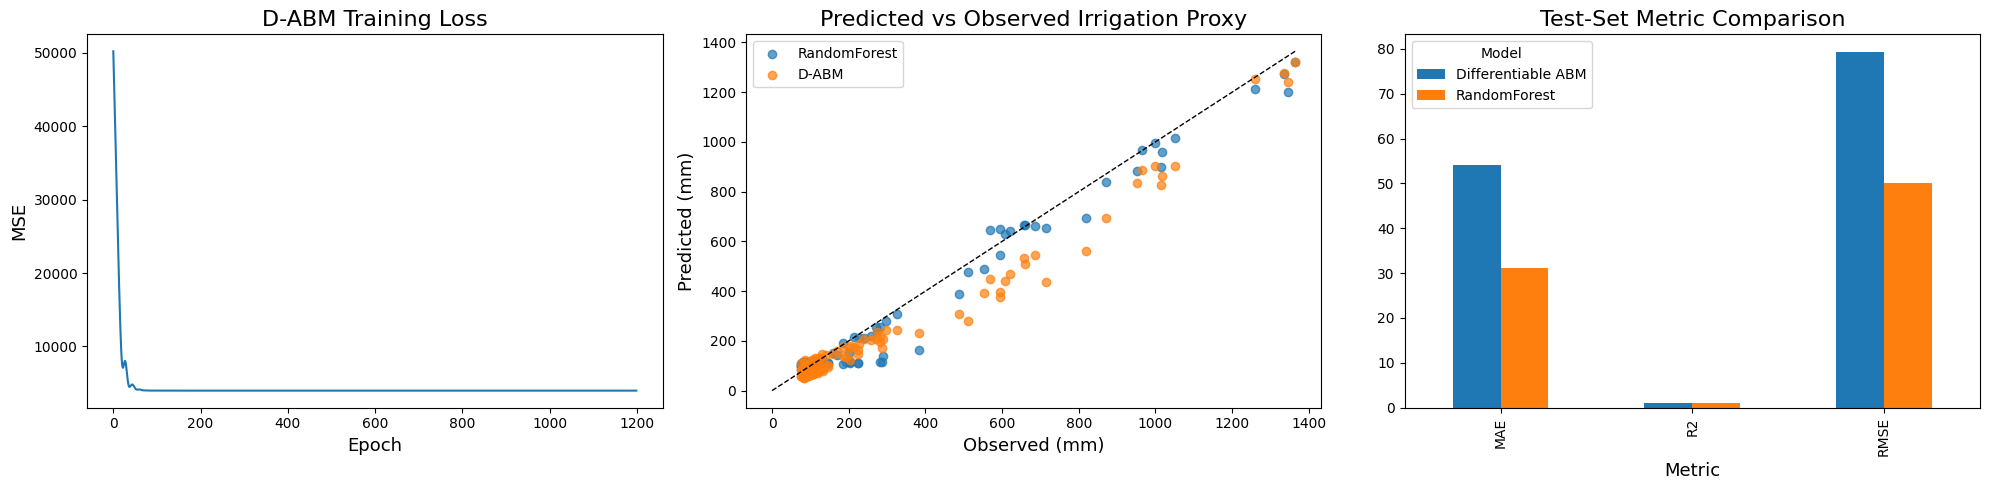

In [13]:
# Model diagnostics
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(loss_history, color="tab:blue")
axes[0].set_title("D-ABM Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")

axes[1].scatter(y_test, rf_pred, alpha=0.7, label="RandomForest")
axes[1].scatter(y_test, dabm_pred, alpha=0.7, label="D-ABM")
mx = max(y_test.max(), rf_pred.max(), dabm_pred.max())
axes[1].plot([0, mx], [0, mx], "k--", lw=1)
axes[1].set_title("Predicted vs Observed Irrigation Proxy")
axes[1].set_xlabel("Observed (mm)")
axes[1].set_ylabel("Predicted (mm)")
axes[1].legend()

metrics_df = pd.DataFrame({
    "Model": ["RandomForest", "Differentiable ABM"],
    "MAE": [rf_mae, dabm_mae],
    "RMSE": [rf_rmse, dabm_rmse],
    "R2": [rf_r2, dabm_r2],
})
metrics_melt = metrics_df.melt(id_vars="Model", var_name="Metric", value_name="Value")
sns.barplot(data=metrics_melt, x="Metric", y="Value", hue="Model", ax=axes[2])
axes[2].set_title("Test-Set Metric Comparison")

plt.tight_layout()
plt.show()


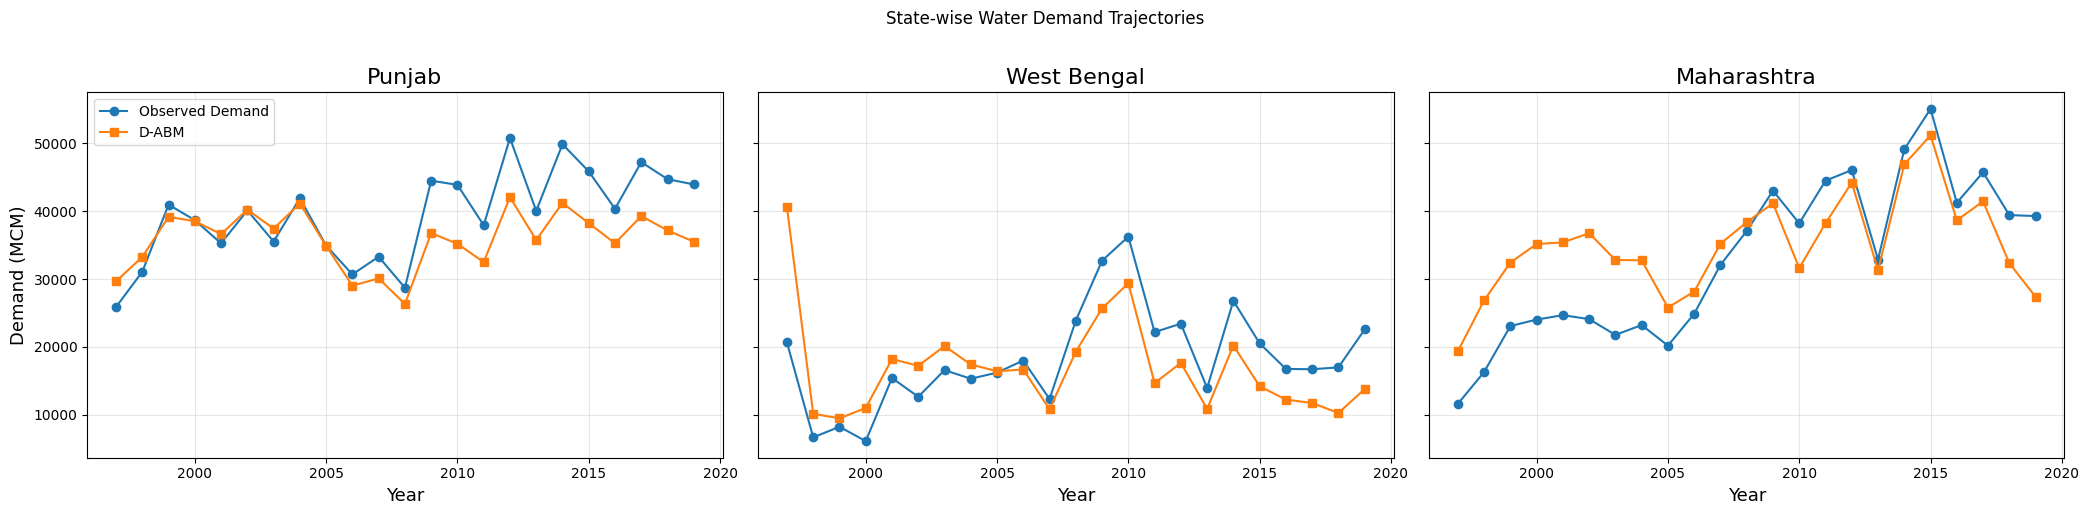

In [17]:
# State-level yearly demand comparison for D-ABM
with torch.no_grad():
    X_all = model_data[feature_cols].values.astype(np.float32)
    X_all_s = (X_all - mu) / sigma
    pred_all = model(
        torch.tensor(X_all_s),
        torch.tensor(model_data["cwr_mm"].values.astype(np.float32))
    ).numpy()

plot_df = model_data[["State", "Crop_Year", "Area", "observed_irrig_mm"]].copy()
plot_df["dabm_irrig_mm"] = pred_all
plot_df["observed_demand_mcm"] = plot_df["observed_irrig_mm"] * plot_df["Area"] * 1e-5
plot_df["dabm_demand_mcm"] = plot_df["dabm_irrig_mm"] * plot_df["Area"] * 1e-5

state_year_cmp = (
    plot_df.groupby(["State", "Crop_Year"], as_index=False)
    .agg({"observed_demand_mcm": "sum", "dabm_demand_mcm": "sum"})
)

fig, axes = plt.subplots(1, 3, figsize=(21, 5), sharey=True)
for ax, st in zip(axes, focus_states):
    temp = state_year_cmp[state_year_cmp["State"] == st]
    ax.plot(temp["Crop_Year"], temp["observed_demand_mcm"], marker="o", label="Observed Demand")
    ax.plot(temp["Crop_Year"], temp["dabm_demand_mcm"], marker="s", label="D-ABM")
    ax.set_title(st)
    ax.set_xlabel("Year")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Demand (MCM)")
axes[0].legend()
plt.suptitle("State-wise Water Demand Trajectories", y=1.02)
plt.tight_layout()
plt.show()


## 6) Climate Scenario: Hotter and Drier Conditions

We test a simple stress scenario:
- Rainfall reduced by 15%
- Mean temperature increased by 10%


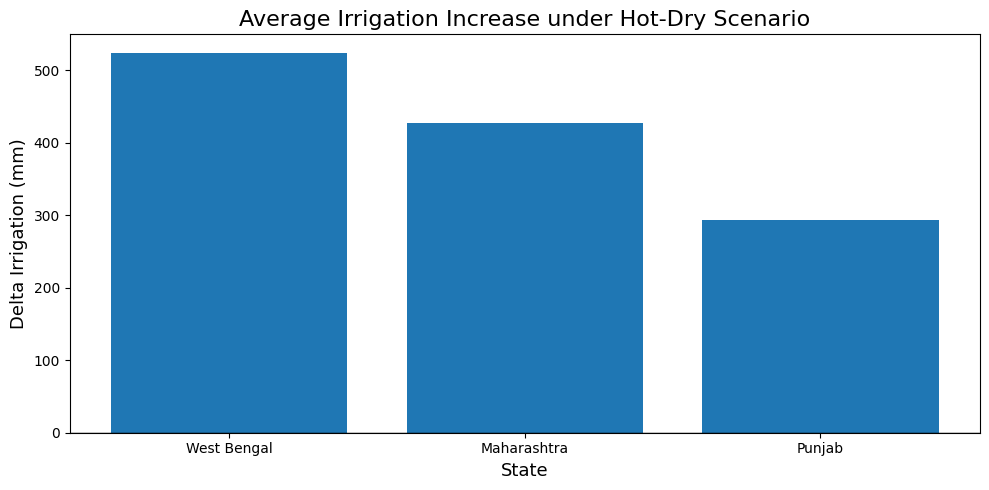

,State,delta_mm
2,West Bengal,523.135498
0,Maharashtra,427.655853
1,Punjab,293.212250


In [15]:
scenario_df = model_data.copy()
scenario_df["rain_mm"] = scenario_df["rain_mm"] * 0.85
scenario_df["temp_mean_c"] = scenario_df["temp_mean_c"] * 1.10
scenario_df["deficit_mm"] = (scenario_df["cwr_mm"] - 0.65 * scenario_df["rain_mm"]).clip(lower=0)

X_scen = scenario_df[feature_cols].values.astype(np.float32)
X_scen_s = (X_scen - mu) / sigma

with torch.no_grad():
    scen_pred_mm = model(
        torch.tensor(X_scen_s),
        torch.tensor(scenario_df["cwr_mm"].values.astype(np.float32))
    ).numpy()

scenario_df["scen_irrig_mm"] = scen_pred_mm
scenario_df["baseline_irrig_mm"] = pred_all
scenario_df["delta_mm"] = scenario_df["scen_irrig_mm"] - scenario_df["baseline_irrig_mm"]

impact = scenario_df.groupby("State", as_index=False)["delta_mm"].mean().sort_values("delta_mm", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=impact, x="State", y="delta_mm", palette="OrRd")
plt.axhline(0, color="black", lw=1)
plt.title("Average Irrigation Increase under Hot-Dry Scenario")
plt.ylabel("Delta Irrigation (mm)")
plt.xlabel("State")
plt.tight_layout()
plt.show()

impact


In [16]:
# Save key outputs
metrics_df.to_csv(OUTPUT_DIR / "model_metrics.csv", index=False)
state_year_cmp.to_csv(OUTPUT_DIR / "state_year_demand_comparison.csv", index=False)
impact.to_csv(OUTPUT_DIR / "scenario_impact_by_state.csv", index=False)
agent_df.to_csv(OUTPUT_DIR / "representative_agent_dataset.csv", index=False)

print("Saved outputs to:", OUTPUT_DIR)
print(sorted([p.name for p in OUTPUT_DIR.glob("*.csv")]))


Saved outputs to: f:\IIT KGP\sem10\Stats in AIML\Course Project\agri_water_demand_outputs
['model_metrics.csv', 'representative_agent_dataset.csv', 'scenario_impact_by_state.csv', 'state_year_demand_comparison.csv']


## 7) Summary

This notebook delivers:
- Multi-source data ingestion (local agricultural records + NASA POWER + World Bank).
- A representative-agent dataset for the three target states.
- A transparent irrigation-demand proxy aligned with agronomic logic.
- Two model tracks: RandomForest baseline and a calibrated differentiable ABM-style model.
- Rich visual diagnostics and a climate stress scenario analysis.

To improve fidelity further, replace the proxy target with district-level observed irrigation withdrawals when available.
